## 0. Introduction and Objective

In [1]:
"""
03_EDA.ipynb

Exploratory Data Analysis (EDA) for Electricity Demand Forecasting

Objective:
-----------
This notebook performs exploratory analysis on electricity demand data
to understand patterns, seasonality, and the impact of festivals/holidays.

Datasets Used:
--------------
1. Daily dataset (2023–2026)
   - max_demand_met_mw (All-India peak demand)
   - festival indicators (is_festival, is_pre, is_post)

2. 15-minute dataset (2025–26)
   - demand_met_mw (high-frequency load data)

Key Questions:
--------------
1. How does electricity demand vary over time?
2. Are there seasonal or weekly patterns?
3. Do festivals significantly affect demand?
4. What intra-day patterns exist in electricity consumption?

Outcome:
---------
The insights from this notebook will guide model selection
and feature engineering for forecasting.
"""

'\n03_EDA.ipynb\n\nExploratory Data Analysis (EDA) for Electricity Demand Forecasting\n\nObjective:\n-----------\nThis notebook performs exploratory analysis on electricity demand data\nto understand patterns, seasonality, and the impact of festivals/holidays.\n\nDatasets Used:\n--------------\n1. Daily dataset (2023–2026)\n   - max_demand_met_mw (All-India peak demand)\n   - festival indicators (is_festival, is_pre, is_post)\n\n2. 15-minute dataset (2025–26)\n   - demand_met_mw (high-frequency load data)\n\nKey Questions:\n--------------\n1. How does electricity demand vary over time?\n2. Are there seasonal or weekly patterns?\n3. Do festivals significantly affect demand?\n4. What intra-day patterns exist in electricity consumption?\n\nOutcome:\n---------\nThe insights from this notebook will guide model selection\nand feature engineering for forecasting.\n'

## 1. Load and Inspect Data

In [2]:
# ================================
# 📦 Import Required Libraries
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for better visuals
sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ================================
# 📂 Define Paths
# ================================

from pathlib import Path

BASE_DIR = Path(r"C:\Users\Shriyans S Sahoo\IIIT Dharwad\Academics\Sem 4\Time Series Forecasting\TimeSeries Project")
DATA_DIR = BASE_DIR / "data" / "processed"

print(f"Base directory: {BASE_DIR}")
print(f"Processed data directory: {DATA_DIR}")

Base directory: C:\Users\Shriyans S Sahoo\IIIT Dharwad\Academics\Sem 4\Time Series Forecasting\TimeSeries Project
Processed data directory: C:\Users\Shriyans S Sahoo\IIIT Dharwad\Academics\Sem 4\Time Series Forecasting\TimeSeries Project\data\processed


In [4]:
# ================================
# 📥 Load Datasets
# ================================

daily_path = DATA_DIR / "daily_all_india_2023_26.csv"
timeseries_path = DATA_DIR / "timeseries_15min_2025_26.csv"

# Load data
daily_df = pd.read_csv(daily_path)
timeseries_df = pd.read_csv(timeseries_path)

# Convert datetime columns
daily_df["date"] = pd.to_datetime(daily_df["date"])
timeseries_df["datetime"] = pd.to_datetime(timeseries_df["datetime"])

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [5]:
# ================================
# 🔍 Basic Inspection
# ================================

def inspect_dataframe(df, name):
    """
    Prints basic information about a dataframe.

    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe to inspect
    name : str
        Name of the dataset (for display purposes)
    """
    print(f"\n===== {name} Dataset =====")
    print(f"Shape: {df.shape}")
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nFirst 5 rows:")
    print(df.head())


# Inspect both datasets
inspect_dataframe(daily_df, "Daily")
inspect_dataframe(timeseries_df, "TimeSeries")


===== Daily Dataset =====
Shape: (1079, 9)

Columns:
['date', 'max_demand_met_mw', 'day_of_week', 'month', 'is_weekend', 'is_festival', 'is_pre', 'is_post', 'festival_name']

First 5 rows:
        date  max_demand_met_mw  day_of_week  month  is_weekend  is_festival  \
0 2023-04-01           180284.0            5      4           1          0.0   
1 2023-04-02           174691.0            6      4           1          0.0   
2 2023-04-03           187729.0            0      4           0          0.0   
3 2023-04-04           189684.0            1      4           0          1.0   
4 2023-04-05           189003.0            2      4           0          0.0   

   is_pre  is_post    festival_name  
0     0.0      1.0       Ram Navami  
1     0.0      0.0             none  
2     1.0      0.0  Mahavir Jayanti  
3     0.0      0.0             none  
4     1.0      0.0  Hanuman Jayanti  

===== TimeSeries Dataset =====
Shape: (33403, 6)

Columns:
['datetime', 'demand_met_mw', 'date', 'ho

In [6]:
# ================================
# 🧪 Data Quality Checks
# ================================

def check_data_quality(df, name):
    """
    Performs basic data quality checks.

    Parameters:
    -----------
    df : pandas.DataFrame
    name : str
    """
    print(f"\n===== Data Quality Check: {name} =====")

    # Missing values
    print("\nMissing Values:")
    print(df.isnull().sum())

    # Duplicate rows
    duplicates = df.duplicated().sum()
    print(f"\nDuplicate Rows: {duplicates}")

    # Data types
    print("\nData Types:")
    print(df.dtypes)


# Run checks
check_data_quality(daily_df, "Daily")
check_data_quality(timeseries_df, "TimeSeries")


===== Data Quality Check: Daily =====

Missing Values:
date                 0
max_demand_met_mw    0
day_of_week          0
month                0
is_weekend           0
is_festival          0
is_pre               0
is_post              0
festival_name        0
dtype: int64

Duplicate Rows: 1

Data Types:
date                 datetime64[ns]
max_demand_met_mw           float64
day_of_week                   int64
month                         int64
is_weekend                    int64
is_festival                 float64
is_pre                      float64
is_post                     float64
festival_name                object
dtype: object

===== Data Quality Check: TimeSeries =====

Missing Values:
datetime         0
demand_met_mw    0
date             0
hour             0
minute           0
day_of_week      0
dtype: int64

Duplicate Rows: 0

Data Types:
datetime         datetime64[ns]
demand_met_mw           float64
date                     object
hour                      int64
minute

In [7]:
# ================================
# 📊 Quick Statistical Summary
# ================================

print("\n===== Daily Demand Summary =====")
print(daily_df["max_demand_met_mw"].describe())

print("\n===== 15-min Demand Summary =====")
print(timeseries_df["demand_met_mw"].describe())


===== Daily Demand Summary =====
count      1079.000000
mean     213281.968554
std       14687.356619
min      159720.000000
25%      204299.500000
50%      213926.000000
75%      222998.000000
max      250070.000000
Name: max_demand_met_mw, dtype: float64

===== 15-min Demand Summary =====
count     33403.000000
mean     195372.697123
std       21344.748499
min      128473.000000
25%      183223.500000
50%      198853.000000
75%      210898.000000
max      245068.000000
Name: demand_met_mw, dtype: float64


In [9]:
# Fixes
daily_df = daily_df.drop_duplicates().reset_index(drop=True)

print(f"Duplicates removed. New shape: {daily_df.shape}")

for col in ["is_festival", "is_pre", "is_post"]:
    daily_df[col] = daily_df[col].astype(int)

timeseries_df["date"] = pd.to_datetime(timeseries_df["date"])

Duplicates removed. New shape: (1078, 9)


## 2. Daily Demand Overview (3-Year Analysis)

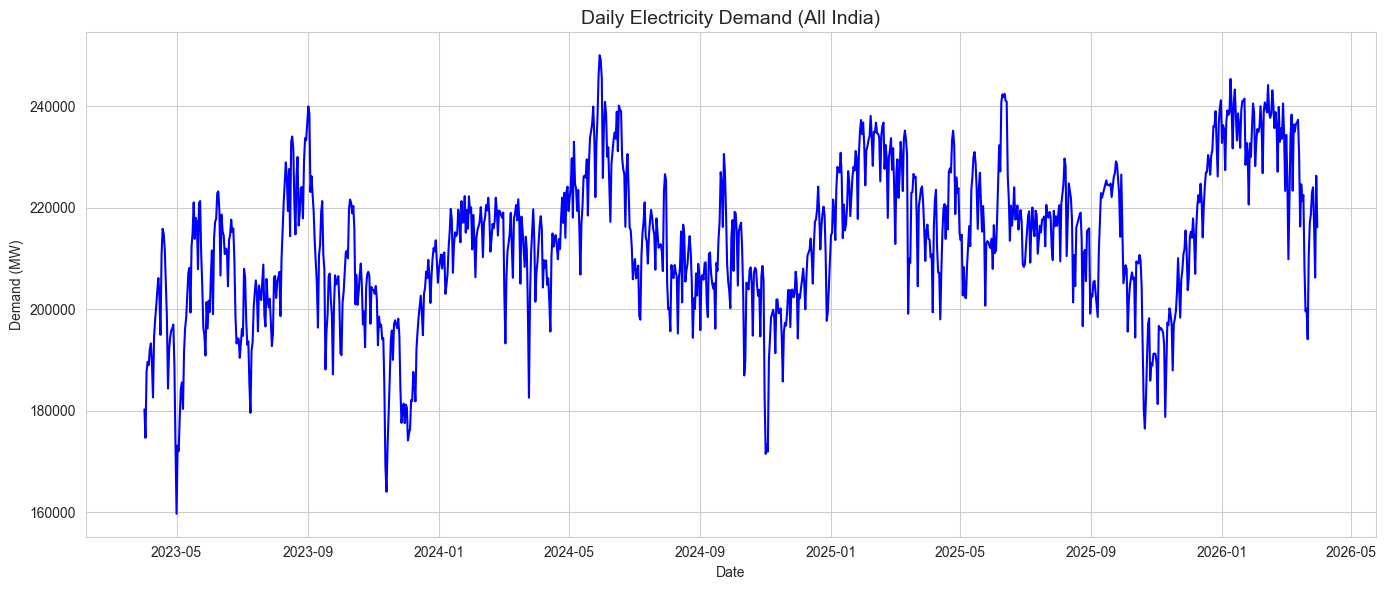

In [10]:
# ================================
# 📈 Daily Demand Trend Over Time
# ================================

# Set date as index for time series plotting
daily_ts = daily_df.set_index("date")

# Plot
plt.figure(figsize=(14, 6))
plt.plot(daily_ts.index, daily_ts["max_demand_met_mw"], color="blue")

plt.title("Daily Electricity Demand (All India)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Demand (MW)")

plt.tight_layout()
plt.show()

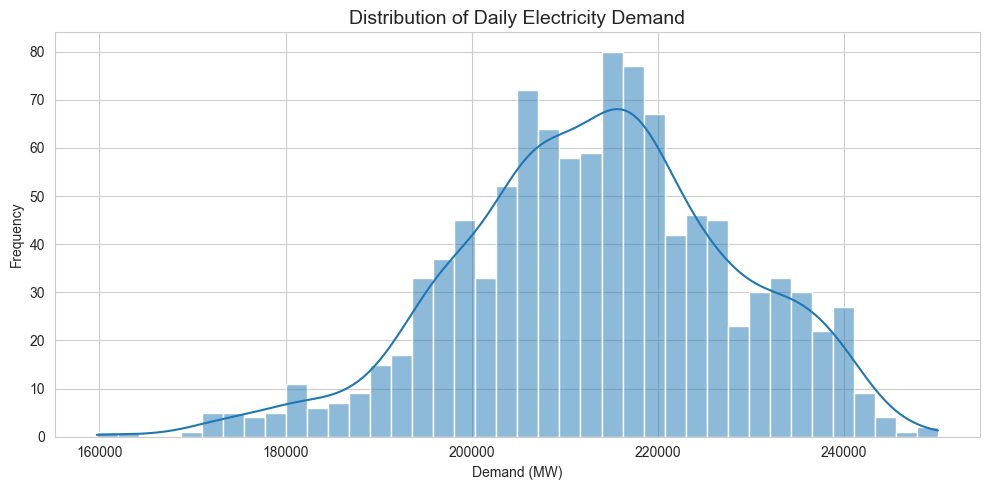

In [11]:
# ================================
# 📊 Distribution of Daily Demand
# ================================

plt.figure(figsize=(10, 5))

sns.histplot(daily_df["max_demand_met_mw"], bins=40, kde=True)

plt.title("Distribution of Daily Electricity Demand", fontsize=14)
plt.xlabel("Demand (MW)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

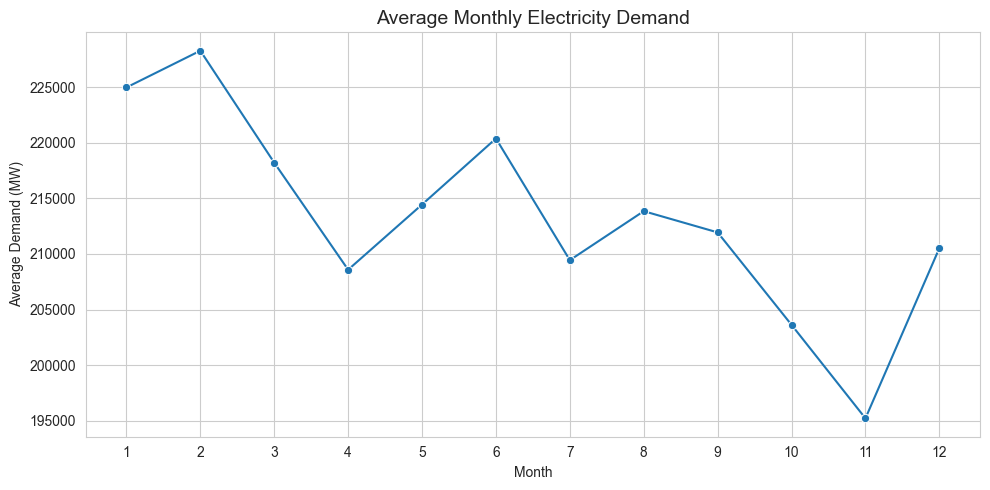

In [12]:
# ================================
# 📅 Monthly Demand Pattern
# ================================

monthly_avg = daily_df.groupby("month")["max_demand_met_mw"].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker="o")

plt.title("Average Monthly Electricity Demand", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Average Demand (MW)")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

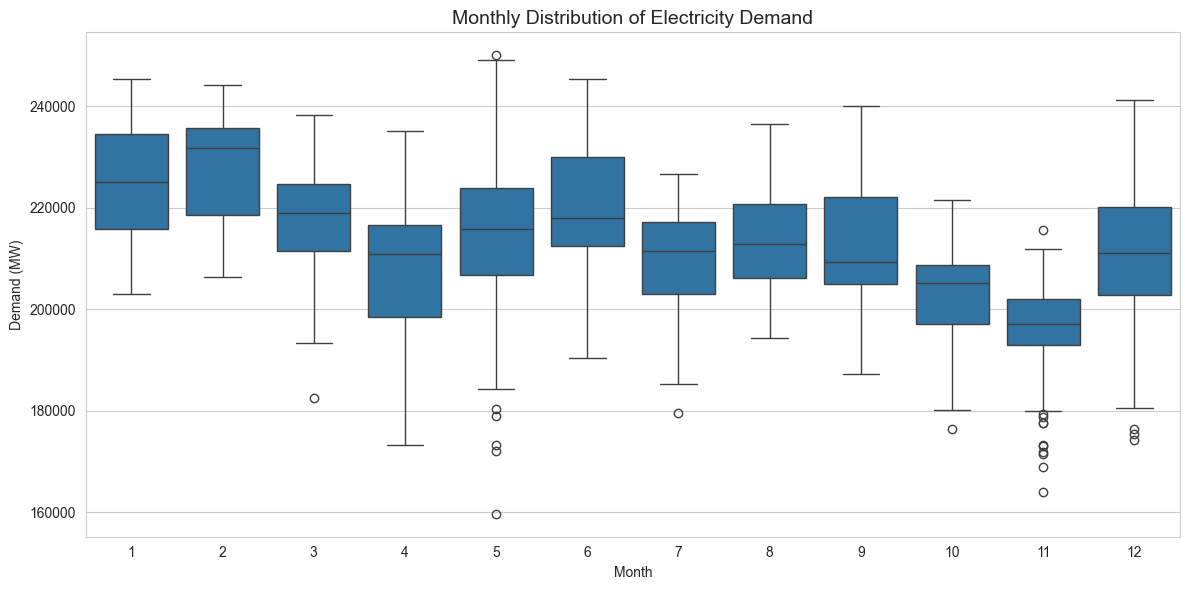

In [13]:
# ================================
# 📦 Monthly Distribution (Boxplot)
# ================================

plt.figure(figsize=(12, 6))

sns.boxplot(x="month", y="max_demand_met_mw", data=daily_df)

plt.title("Monthly Distribution of Electricity Demand", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Demand (MW)")

plt.tight_layout()
plt.show()

In [14]:
print("\nTop 5 highest demand days:")
print(daily_df.nlargest(5, "max_demand_met_mw")[["date", "max_demand_met_mw"]])


Top 5 highest demand days:
          date  max_demand_met_mw
425 2024-05-30           250070.0
426 2024-05-31           249159.0
424 2024-05-29           246069.0
427 2024-06-01           245419.0
996 2026-01-09           245416.0


## 3. Weekly Patterns

In [15]:
# ================================
# 📊 Weekday vs Weekend Demand
# ================================

# Compute averages
weekday_avg = daily_df[daily_df["is_weekend"] == 0]["max_demand_met_mw"].mean()
weekend_avg = daily_df[daily_df["is_weekend"] == 1]["max_demand_met_mw"].mean()

print(f"Average Weekday Demand: {weekday_avg:.2f} MW")
print(f"Average Weekend Demand: {weekend_avg:.2f} MW")

Average Weekday Demand: 214928.80 MW
Average Weekend Demand: 209119.62 MW


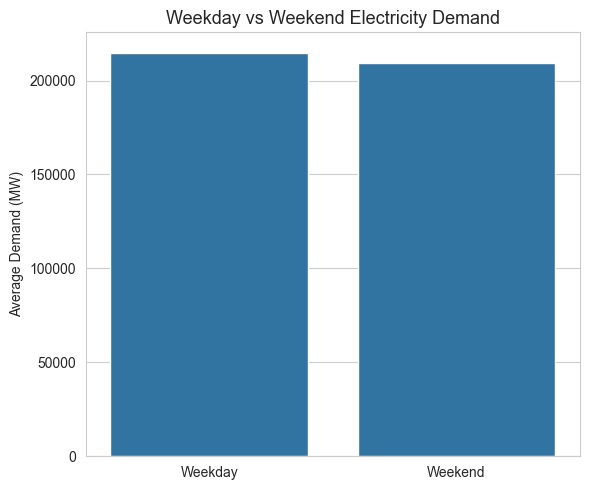

In [16]:
# ================================
# 📊 Visualization: Weekday vs Weekend
# ================================

plt.figure(figsize=(6, 5))

sns.barplot(
    x=["Weekday", "Weekend"],
    y=[weekday_avg, weekend_avg]
)

plt.title("Weekday vs Weekend Electricity Demand", fontsize=13)
plt.ylabel("Average Demand (MW)")

plt.tight_layout()
plt.show()

In [17]:
# ================================
# 📅 Demand by Day of Week
# ================================

dow_avg = daily_df.groupby("day_of_week")["max_demand_met_mw"].mean()

# Map numeric to names
day_mapping = {
    0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu",
    4: "Fri", 5: "Sat", 6: "Sun"
}

dow_avg.index = dow_avg.index.map(day_mapping)

print("\nAverage demand by day of week:")
print(dow_avg)


Average demand by day of week:
day_of_week
Mon    213774.441852
Tue    214666.973856
Wed    215231.136364
Thu    215049.752145
Fri    215939.828947
Sat    213259.735484
Sun    204952.616883
Name: max_demand_met_mw, dtype: float64


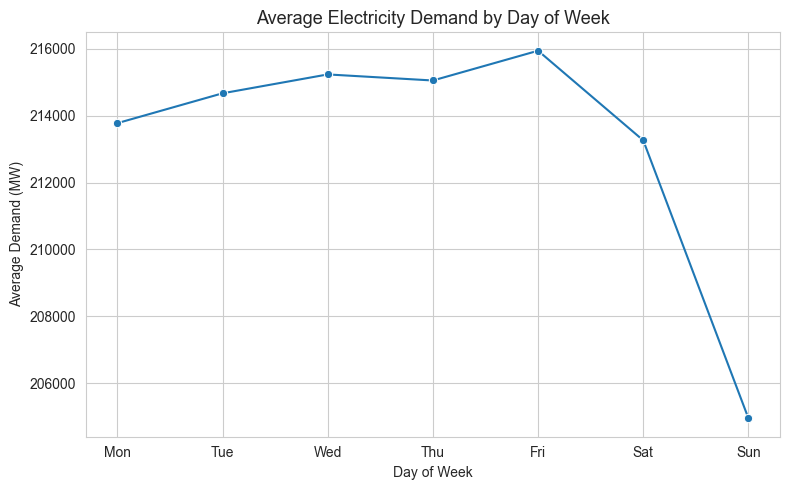

In [18]:
# ================================
# 📊 Visualization: Day-of-Week Pattern
# ================================

plt.figure(figsize=(8, 5))

sns.lineplot(x=dow_avg.index, y=dow_avg.values, marker="o")

plt.title("Average Electricity Demand by Day of Week", fontsize=13)
plt.xlabel("Day of Week")
plt.ylabel("Average Demand (MW)")

plt.tight_layout()
plt.show()

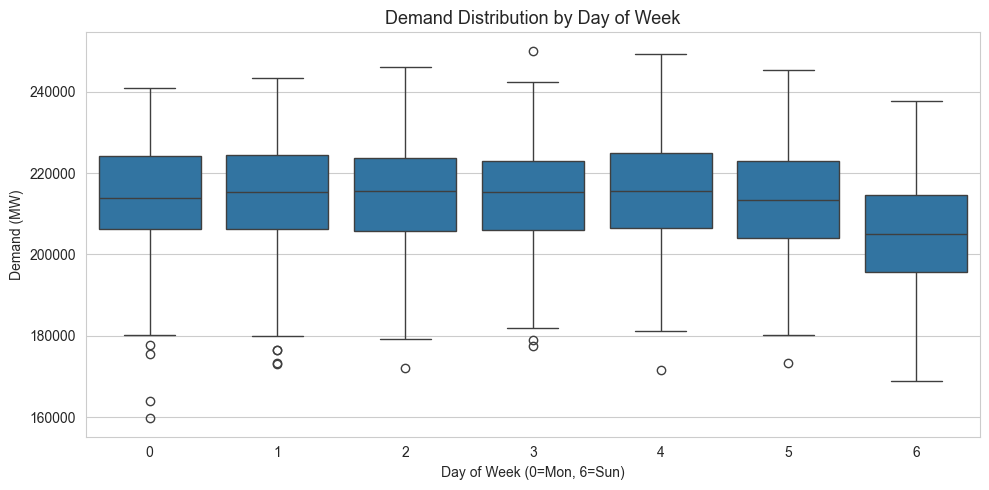

In [19]:
# ================================
# 📦 Distribution by Day of Week
# ================================

plt.figure(figsize=(10, 5))

sns.boxplot(x="day_of_week", y="max_demand_met_mw", data=daily_df)

plt.title("Demand Distribution by Day of Week", fontsize=13)
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.ylabel("Demand (MW)")

plt.tight_layout()
plt.show()

## 4. Festival Impact

In [20]:
# ================================
# 🎉 Festival vs Non-Festival Demand
# ================================

festival_avg = daily_df[daily_df["is_festival"] == 1]["max_demand_met_mw"].mean()
non_festival_avg = daily_df[daily_df["is_festival"] == 0]["max_demand_met_mw"].mean()

print(f"Average Demand on Festival Days: {festival_avg:.2f} MW")
print(f"Average Demand on Non-Festival Days: {non_festival_avg:.2f} MW")

Average Demand on Festival Days: 207248.22 MW
Average Demand on Non-Festival Days: 213905.95 MW


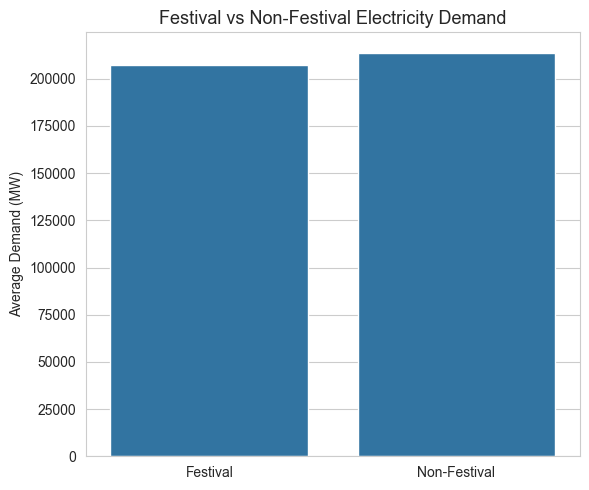

In [21]:
# ================================
# 📊 Visualization
# ================================

plt.figure(figsize=(6, 5))

sns.barplot(
    x=["Festival", "Non-Festival"],
    y=[festival_avg, non_festival_avg]
)

plt.title("Festival vs Non-Festival Electricity Demand", fontsize=13)
plt.ylabel("Average Demand (MW)")

plt.tight_layout()
plt.show()

In [22]:
# ================================
# 🔁 Pre vs Festival vs Post
# ================================

pre_avg = daily_df[daily_df["is_pre"] == 1]["max_demand_met_mw"].mean()
festival_avg = daily_df[daily_df["is_festival"] == 1]["max_demand_met_mw"].mean()
post_avg = daily_df[daily_df["is_post"] == 1]["max_demand_met_mw"].mean()

print(f"Pre-Festival Demand: {pre_avg:.2f} MW")
print(f"Festival Day Demand: {festival_avg:.2f} MW")
print(f"Post-Festival Demand: {post_avg:.2f} MW")

Pre-Festival Demand: 212568.92 MW
Festival Day Demand: 207248.22 MW
Post-Festival Demand: 212636.63 MW


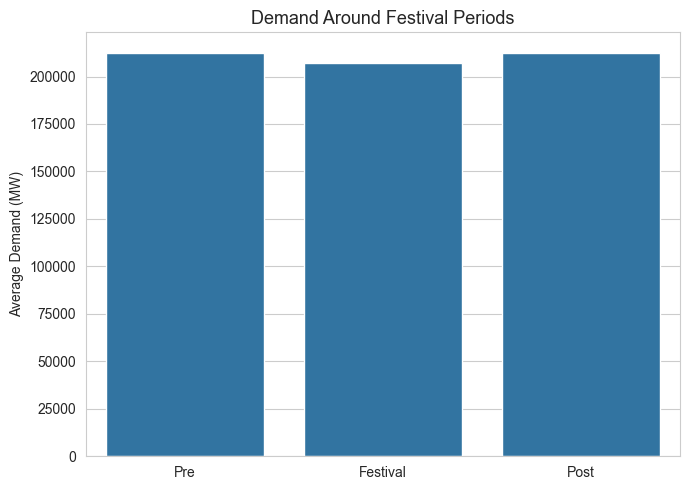

In [23]:
# ================================
# 📊 Visualization
# ================================

plt.figure(figsize=(7, 5))

sns.barplot(
    x=["Pre", "Festival", "Post"],
    y=[pre_avg, festival_avg, post_avg]
)

plt.title("Demand Around Festival Periods", fontsize=13)
plt.ylabel("Average Demand (MW)")

plt.tight_layout()
plt.show()

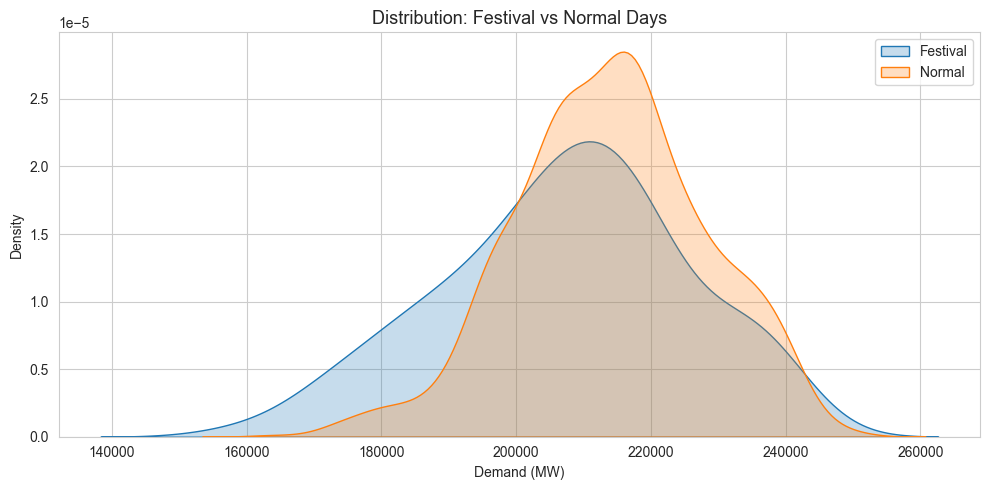

In [26]:
# ================================
# 📊 Festival vs Normal Comparison
# ================================

festival_days = daily_df[daily_df["is_festival"] == 1]
normal_days = daily_df[daily_df["is_festival"] == 0]

plt.figure(figsize=(10, 5))

sns.kdeplot(festival_days["max_demand_met_mw"], label="Festival", fill=True)
sns.kdeplot(normal_days["max_demand_met_mw"], label="Normal", fill=True)

plt.title("Distribution: Festival vs Normal Days", fontsize=13)
plt.xlabel("Demand (MW)")

plt.legend()
plt.tight_layout()
plt.show()

## 15-minute Load Curve Analysis

In [31]:
# ================================
# ⏱️ Create Time Block (0–95)
# ================================

"""
Each day has 96 time blocks (15-minute intervals).
We convert hour + minute into a single index.
"""

timeseries_df["time_block"] = (
    timeseries_df["hour"] * 4 + timeseries_df["minute"] // 15
)

In [32]:
# ================================
# 📊 Average Daily Load Curve
# ================================

"""
We average demand across all days for each time block.
This gives a typical daily demand pattern.
"""

avg_curve = (
    timeseries_df
    .groupby("time_block")["demand_met_mw"]
    .mean()
)

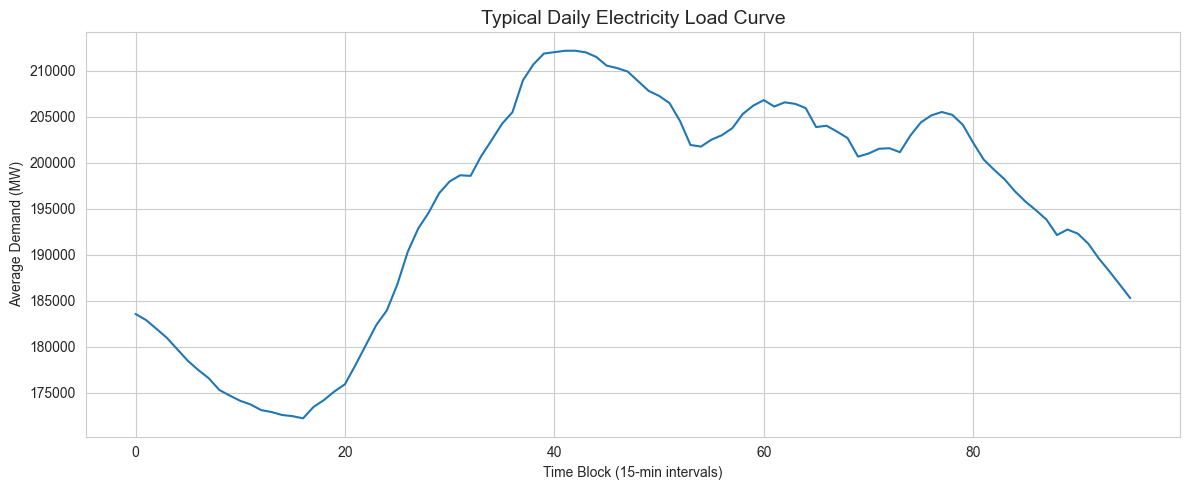

In [33]:
# ================================
# 📈 Typical Daily Load Curve
# ================================

plt.figure(figsize=(12, 5))

plt.plot(avg_curve.index, avg_curve.values)

plt.title("Typical Daily Electricity Load Curve", fontsize=14)
plt.xlabel("Time Block (15-min intervals)")
plt.ylabel("Average Demand (MW)")

plt.tight_layout()
plt.show()

In [34]:
# ================================
# 🕒 Hourly Demand Pattern
# ================================

hourly_avg = (
    timeseries_df
    .groupby("hour")["demand_met_mw"]
    .mean()
)

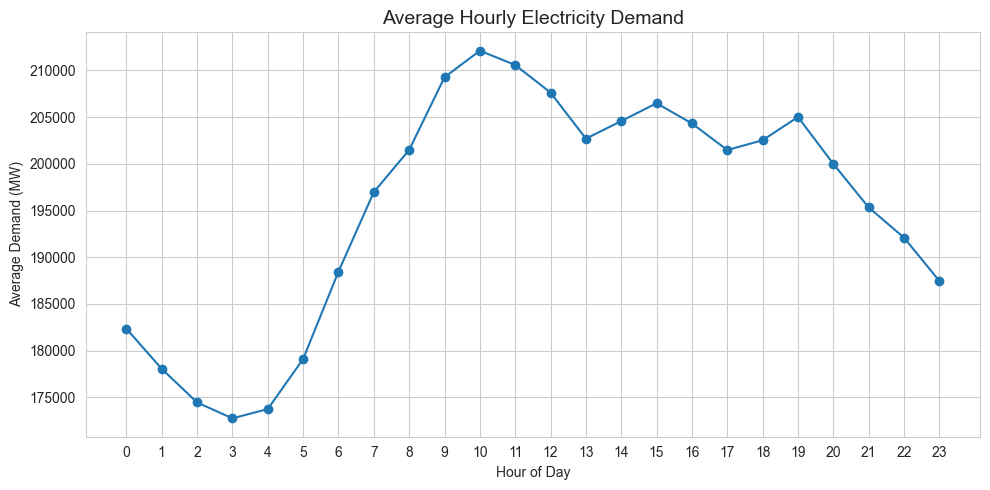

In [35]:
# ================================
# 📈 Hourly Demand Curve
# ================================

plt.figure(figsize=(10, 5))

plt.plot(hourly_avg.index, hourly_avg.values, marker="o")

plt.title("Average Hourly Electricity Demand", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand (MW)")

plt.xticks(range(0, 24))

plt.tight_layout()
plt.show()

In [36]:
# ================================
# 🔝 Peak Demand Time Analysis
# ================================

"""
Find the time block where demand is highest on average.
"""

peak_block = avg_curve.idxmax()
peak_value = avg_curve.max()

print(f"Peak occurs at time block: {peak_block}")
print(f"Peak demand: {peak_value:.2f} MW")

Peak occurs at time block: 42
Peak demand: 212199.64 MW


In [37]:
# Convert time_block → hour:minute
peak_hour = peak_block // 4
peak_minute = (peak_block % 4) * 15

print(f"Peak time: {peak_hour:02d}:{peak_minute:02d}")

Peak time: 10:30


## 6. Festival v/s Normal Load Curves

In [38]:
# ================================
# 🎯 Separate Festival vs Normal
# ================================

festival_ts = timeseries_df[
    timeseries_df["date"].isin(
        daily_df[daily_df["is_festival"] == 1]["date"]
    )
]

normal_ts = timeseries_df[
    timeseries_df["date"].isin(
        daily_df[daily_df["is_festival"] == 0]["date"]
    )
]

In [39]:
# ================================
# 📊 Average curves for both groups
# ================================

festival_curve = (
    festival_ts
    .groupby("time_block")["demand_met_mw"]
    .mean()
)

normal_curve = (
    normal_ts
    .groupby("time_block")["demand_met_mw"]
    .mean()
)

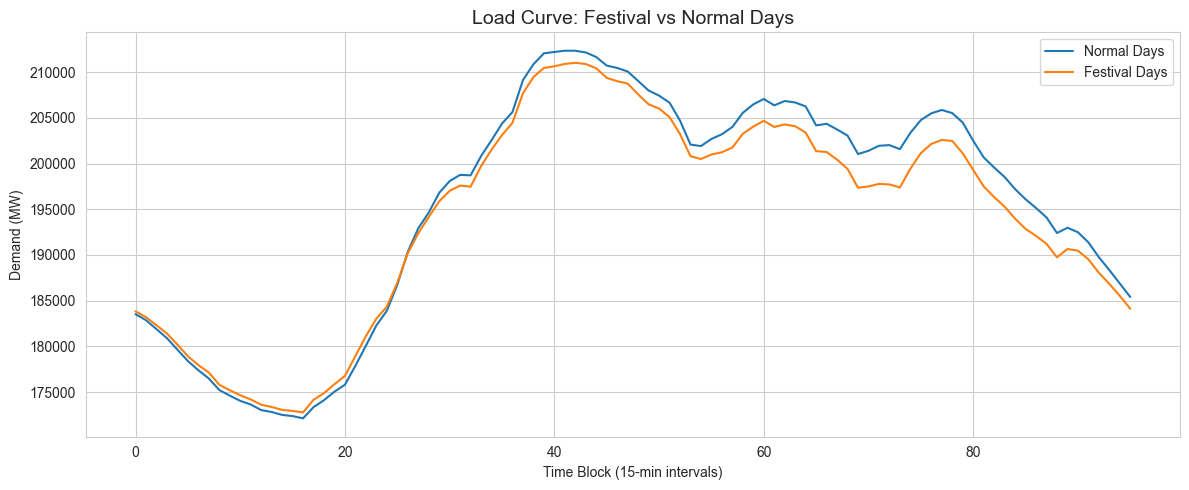

In [40]:
# ================================
# 📈 Festival vs Normal Load Curve
# ================================

plt.figure(figsize=(12, 5))

plt.plot(normal_curve.index, normal_curve.values, label="Normal Days")
plt.plot(festival_curve.index, festival_curve.values, label="Festival Days")

plt.title("Load Curve: Festival vs Normal Days", fontsize=14)
plt.xlabel("Time Block (15-min intervals)")
plt.ylabel("Demand (MW)")

plt.legend()
plt.tight_layout()
plt.show()

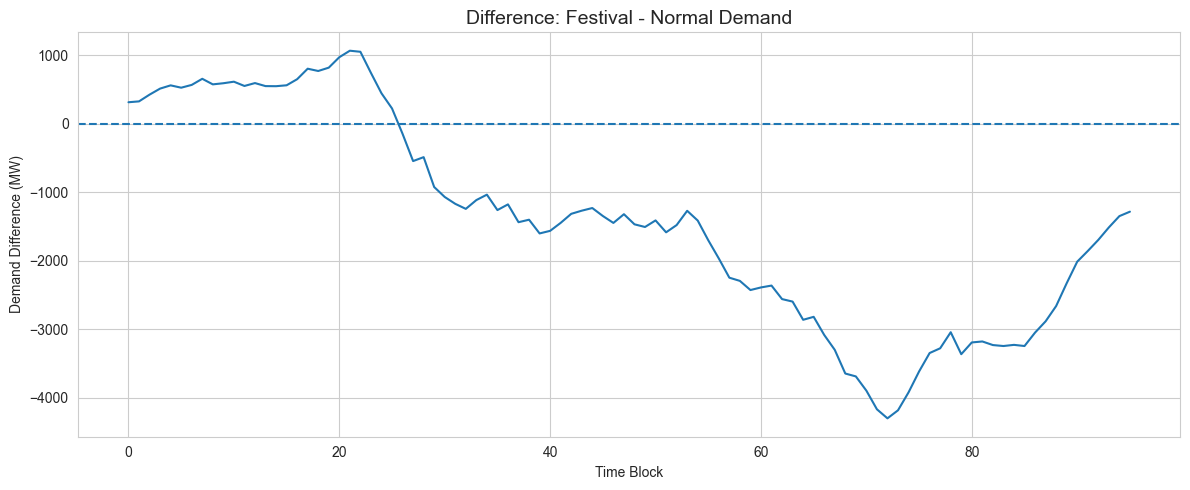

In [41]:
# ================================
# 📉 Difference Curve
# ================================

diff_curve = festival_curve - normal_curve

plt.figure(figsize=(12, 5))

plt.plot(diff_curve.index, diff_curve.values)

plt.axhline(0, linestyle="--")

plt.title("Difference: Festival - Normal Demand", fontsize=14)
plt.xlabel("Time Block")
plt.ylabel("Demand Difference (MW)")

plt.tight_layout()
plt.show()

In [42]:
# ================================
# 🔍 Summary stats
# ================================

print(f"Average difference: {diff_curve.mean():.2f} MW")
print(f"Max increase: {diff_curve.max():.2f} MW")
print(f"Max decrease: {diff_curve.min():.2f} MW")

Average difference: -1423.27 MW
Max increase: 1066.53 MW
Max decrease: -4299.79 MW


## 7. Feature Engineering

In [43]:
# ================================
# 📅 Time-based Features (Daily)
# ================================

"""
Create basic time features for daily dataset
"""

daily_df["day_of_week"] = daily_df["date"].dt.dayofweek
daily_df["month"] = daily_df["date"].dt.month

# Weekend flag (already exists, but ensure consistency)
daily_df["is_weekend"] = (daily_df["day_of_week"] >= 5).astype(int)

In [44]:
# ================================
# 🔄 Cyclical Encoding
# ================================

import numpy as np

# Day of week
daily_df["dow_sin"] = np.sin(2 * np.pi * daily_df["day_of_week"] / 7)
daily_df["dow_cos"] = np.cos(2 * np.pi * daily_df["day_of_week"] / 7)

# Month
daily_df["month_sin"] = np.sin(2 * np.pi * daily_df["month"] / 12)
daily_df["month_cos"] = np.cos(2 * np.pi * daily_df["month"] / 12)

In [45]:
# ================================
# ⏳ Lag Features
# ================================

"""
Lag features capture previous demand patterns
"""

daily_df = daily_df.sort_values("date")

# 1-day lag
daily_df["lag_1"] = daily_df["max_demand_met_mw"].shift(1)

# 7-day lag (weekly pattern)
daily_df["lag_7"] = daily_df["max_demand_met_mw"].shift(7)

# 30-day lag (monthly trend)
daily_df["lag_30"] = daily_df["max_demand_met_mw"].shift(30)

In [46]:
# ================================
# 📈 Rolling Features
# ================================

# 7-day rolling mean
daily_df["rolling_mean_7"] = daily_df["max_demand_met_mw"].rolling(7).mean()

# 7-day rolling std
daily_df["rolling_std_7"] = daily_df["max_demand_met_mw"].rolling(7).std()

In [47]:
# ================================
# 🎉 Festival Features
# ================================

# Already present, just ensure integer type
daily_df["is_festival"] = daily_df["is_festival"].astype(int)
daily_df["is_pre"] = daily_df["is_pre"].astype(int)
daily_df["is_post"] = daily_df["is_post"].astype(int)

In [48]:
# ================================
# 🧹 Drop NaNs
# ================================

daily_df = daily_df.dropna().reset_index(drop=True)

print("Final shape:", daily_df.shape)

Final shape: (1048, 18)


In [49]:
# ================================
# ⏱️ Time Features (15-min)
# ================================

timeseries_df["hour"] = timeseries_df["datetime"].dt.hour
timeseries_df["minute"] = timeseries_df["datetime"].dt.minute

# Cyclical encoding
timeseries_df["hour_sin"] = np.sin(2 * np.pi * timeseries_df["hour"] / 24)
timeseries_df["hour_cos"] = np.cos(2 * np.pi * timeseries_df["hour"] / 24)

In [50]:
# ================================
# ⏳ Lag Features (15-min)
# ================================

timeseries_df = timeseries_df.sort_values("datetime")

# Previous timestep (15 min)
timeseries_df["lag_1"] = timeseries_df["demand_met_mw"].shift(1)

# 1 day lag (96 intervals)
timeseries_df["lag_96"] = timeseries_df["demand_met_mw"].shift(96)

In [51]:
# ================================
# 🔗 Merge festival flags
# ================================

ts_features = daily_df[["date", "is_festival", "is_pre", "is_post"]]

timeseries_df = timeseries_df.merge(ts_features, on="date", how="left")

In [52]:
# ================================
# 🧹 Final Cleanup
# ================================

timeseries_df = timeseries_df.dropna().reset_index(drop=True)

print("Final TS shape:", timeseries_df.shape)

Final TS shape: (33307, 14)


In [57]:
# ================================
# 📈 Save the datasets created
# ================================

from pathlib import Path

base_path = Path(r"C:\Users\Shriyans S Sahoo\IIIT Dharwad\Academics\Sem 4\Time Series Forecasting\TimeSeries Project")

processed_dir = base_path / "data" / "processed"

daily_df.to_csv(processed_dir / "daily_features.csv", index=False)
timeseries_df.to_csv(processed_dir / "timeseries_features.csv", index=False)